In [30]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          16-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split

data = pd.read_csv("data_train.csv", sep = ",")
data_train, data_test = train_test_split(data, test_size = 0.3, random_state = 1987)


In [31]:
X_train = data_train.drop(columns = ['Churn'])
Y_train = data_train["Churn"]
X_test = data_test.drop(columns = ['Churn'])
Y_test = data_test["Churn"]


In [32]:
gridsearch = GridSearchCV(
    estimator = SVC(probability = True), 
    param_grid = [{
        'C':[0.01, 0.1, 1, 10], 
        'gamma':[0.01, 0.1, 1, 10]}],
    scoring = 'accuracy',
    verbose = 2)

gridsearch.fit(X_train, Y_train)
gridsearch.best_estimator_


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .................................C=0.01, gamma=0.01; total time=   0.3s
[CV] END .................................C=0.01, gamma=0.01; total time=   0.2s
[CV] END .................................C=0.01, gamma=0.01; total time=   0.2s
[CV] END .................................C=0.01, gamma=0.01; total time=   0.3s
[CV] END .................................C=0.01, gamma=0.01; total time=   0.3s
[CV] END ..................................C=0.01, gamma=0.1; total time=   0.3s
[CV] END ..................................C=0.01, gamma=0.1; total time=   0.5s
[CV] END ..................................C=0.01, gamma=0.1; total time=   0.3s
[CV] END ..................................C=0.01, gamma=0.1; total time=   0.3s
[CV] END ..................................C=0.01, gamma=0.1; total time=   0.2s
[CV] END ....................................C=0.01, gamma=1; total time=   0.3s
[CV] END ....................................C=0

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [33]:
predicted = gridsearch.predict(X_test)


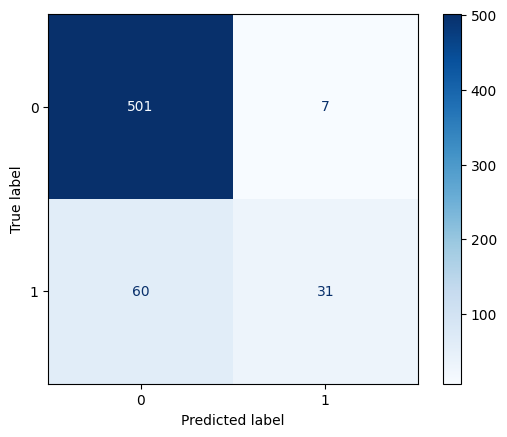

In [34]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(Y_test, predicted, cmap = 'Blues')
plt.show()